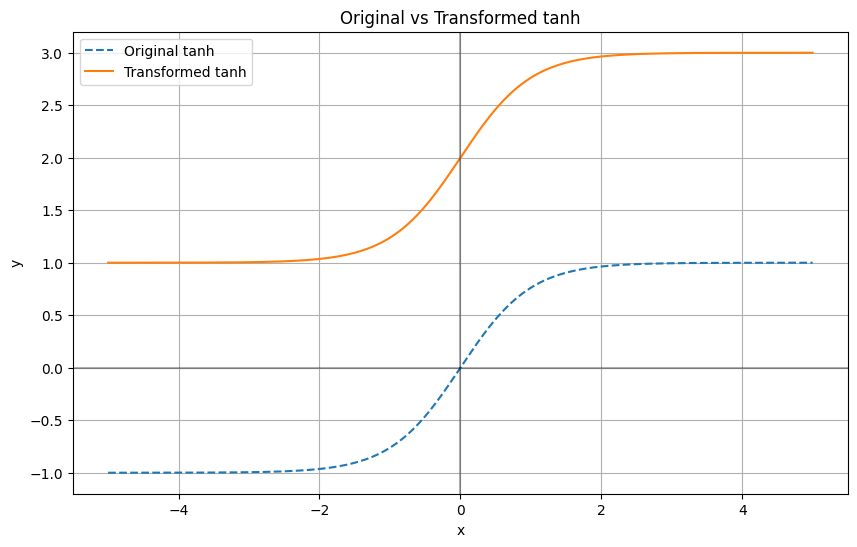

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Create input values
x = np.linspace(-5, 5, 200)

# Original tanh
y_original = np.tanh(x)

# Transformed tanh with your parameters
vertical_scaling = 1
horizontal_scaling = 1
vertical_shift = 2
y_transformed = vertical_shift + vertical_scaling * np.tanh(x / horizontal_scaling)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y_original, label='Original tanh', linestyle='--')
plt.plot(x, y_transformed, label='Transformed tanh')
plt.grid(True)
plt.legend()
plt.title('Original vs Transformed tanh')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

/var/folders/48/l13wwcrn4g34_y7bgnwynx7c0000gn/T/ipykernel_23052/4172808534.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


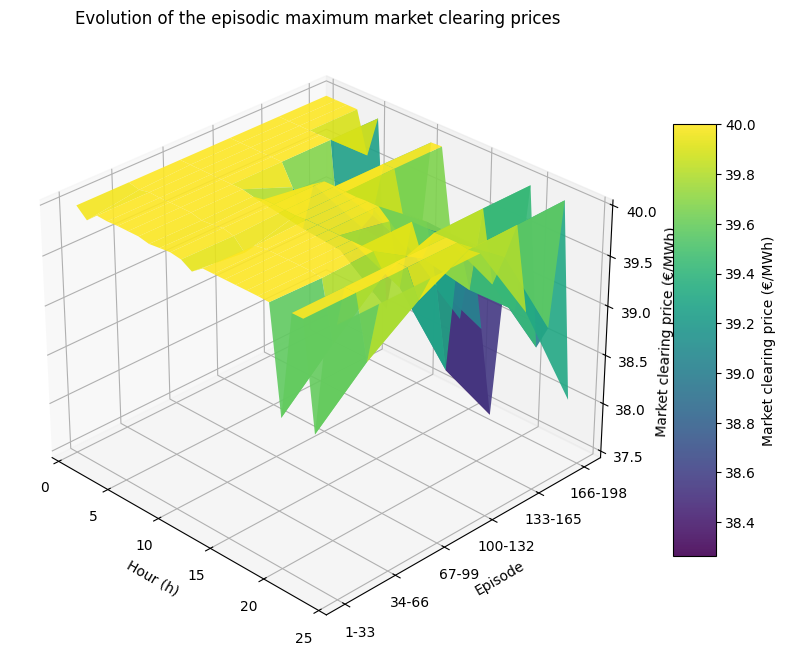

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Load the saved episode data from the specified path
episode_data = torch.load('/Users/andrewsmith/Documents/projects/rl-power-markets/episode_data.pt').detach()

# truncate first 30 episodes
episode_data = episode_data[30:]

# Extract the market clearing prices (first channel of the data)
# Shape: (episodes, hours)
prices = episode_data[:, :, 0].detach().numpy()

# Define the number of episodes and hours
num_episodes = prices.shape[0]
num_hours = prices.shape[1]

# Create episode bins for visualization (similar to the paper)
# We'll create 6 bins as shown in the figure
bin_size = num_episodes // 6
episode_bins = []
bin_labels = []

for i in range(6):
    start_idx = i * bin_size
    end_idx = min((i+1) * bin_size, num_episodes)
    
    # Calculate maximum prices for this bin (instead of mean)
    bin_max_prices = np.max(prices[start_idx:end_idx], axis=0)
    episode_bins.append(bin_max_prices)
    
    # Create label for this bin
    bin_labels.append(f'{start_idx+1}-{end_idx}')

# Create meshgrid for 3D surface
hours = np.arange(1, num_hours + 1)
bin_indices = np.arange(len(episode_bins))
X, Y = np.meshgrid(hours, bin_indices)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a single 3D surface with color based on price
Z = np.array(episode_bins)

# Plot the surface with color based on price values
surf = ax.plot_surface(
    X, Y, Z, 
    cmap='viridis',  # Use a colormap that transitions well for prices
    edgecolor='none',
    alpha=0.9,
    antialiased=True
)

# Set labels and title
ax.set_xlabel('Hour (h)')
ax.set_ylabel('Episode')
ax.set_zlabel('Market clearing price (€/MWh)')
ax.set_title('Evolution of the episodic maximum market clearing prices')

# Set y-ticks to show bin labels
ax.set_yticks(np.arange(len(episode_bins)))
ax.set_yticklabels(bin_labels)

# Adjust view angle to match the paper
ax.view_init(elev=30, azim=-45)

# Add a colorbar to show the price scale
cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=10)
cbar.set_label('Market clearing price (€/MWh)')

plt.tight_layout()
plt.show()